# SSL-предобучения (100k BigP3BCI → 1D U-Net masked reconstruction)

## Путь к zarr

In [1]:
!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.0 MB/s eta 0:00:00


In [2]:
import os, glob
print(glob.glob("/kaggle/input/*/*/*"))

['/kaggle/input/datasets/taisiyaglazova/ssl-bigp3bci-zarr', '/kaggle/input/datasets/taisiyaglazova/ssl-bigp3bci-train-val-subset-100k']


In [3]:
import json
import random
from collections import Counter
import zarr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## Subset и split (done once)

In [4]:
# zarr_path = "/kaggle/input/datasets/taisiyaglazova/ssl-bigp3bci-zarr/ssl_bigp3bci.zarr"

# root = zarr.open(zarr_path, mode="r")
# print(root["X"].shape)

### 2) Проверка чтения данных и базовый sanity check

In [5]:
# X = root["X"]

# print("Shape:", X.shape)
# print("Dtype:", X.dtype)

In [6]:
# idx = np.random.choice(X.shape[0], size=5, replace=False)
# sample = X.get_orthogonal_selection((idx, slice(None), slice(None)))

# print("Sample shape:", sample.shape)

In [7]:
# # визуализация

# epoch = sample[0]            # (14, 208)
# epoch_uv = epoch * 1e6       # перевод в µV

# plt.figure(figsize=(12,4))

# offset = 20  # вертикальный offset между каналами

# for c in range(5):
#     plt.plot(epoch_uv[c] + c*offset)

# plt.title("EEG epoch (first 5 channels, µV)")
# plt.xlabel("Time")
# plt.ylabel("Amplitude (µV, offset)")
# plt.show()

### SSL subset и split по субъектам

In [8]:
# subject_ids = np.asarray(root['meta']['subject_id'])
# print("subject_ids shape:", subject_ids.shape)
# print("example:", subject_ids[-10:])

In [9]:
# # Полезные функции
# def summarize_subject_distribution(subject_ids):
#     """
#     Prints basic stats for number of epochs per subject.
#     """
#     subject_ids = np.asarray(subject_ids)
#     unique_subjects, counts = np.unique(subject_ids, return_counts=True)

#     print(f"Total epochs   : {len(subject_ids):,}")
#     print(f"Total subjects : {len(unique_subjects)}")
#     print(f"Min epochs/subj: {counts.min():,}")
#     print(f"Median         : {int(np.median(counts)):,}")
#     print(f"Mean           : {counts.mean():.2f}")
#     print(f"Max epochs/subj: {counts.max():,}")

#     top_idx = np.argsort(counts)[::-1][:10]
#     print("\nTop-10 subjects by number of epochs:")
#     for i in top_idx:
#         print(f"  {unique_subjects[i]} -> {counts[i]:,}")


# def build_subject_to_indices(subject_ids):
#     """
#     Returns dict: subject_id -> np.ndarray of epoch indices
#     """
#     subject_ids = np.asarray(subject_ids)
#     subject_to_indices = {}

#     for subj in np.unique(subject_ids):
#         idx = np.where(subject_ids == subj)[0]
#         subject_to_indices[subj] = idx

#     return subject_to_indices


# def select_subject_subset(
#     subject_to_indices,
#     target_n_epochs=100_000,
#     min_n_epochs=90_000,
#     max_n_epochs=110_000,
#     seed=2026,
# ):
#     """
#     Randomly shuffles subjects and keeps adding full subjects until
#     total number of epochs is close to target_n_epochs.

#     Strategy:
#     - subjects are added whole
#     - if adding the next subject gives a total closer to target than stopping now,
#       we include that subject
#     - final size is allowed to be around target, ideally within [min_n_epochs, max_n_epochs]
#     """
#     rng = np.random.default_rng(seed)

#     subjects = np.array(list(subject_to_indices.keys()), dtype=object)
#     rng.shuffle(subjects)

#     selected_subjects = []
#     total = 0

#     for subj in subjects:
#         n_subj = len(subject_to_indices[subj])

#         if total == 0:
#             selected_subjects.append(subj)
#             total += n_subj
#             continue

#         # Если уже в допустимом диапазоне, решаем:
#         # добавить следующего субъекта или остановиться
#         if min_n_epochs <= total <= max_n_epochs:
#             current_diff = abs(total - target_n_epochs)
#             next_diff = abs((total + n_subj) - target_n_epochs)

#             if next_diff < current_diff:
#                 selected_subjects.append(subj)
#                 total += n_subj
#             break

#         selected_subjects.append(subj)
#         total += n_subj

#     return selected_subjects, total


# def make_subject_level_split(selected_subjects, val_ratio=0.2, seed=2026):
#     """
#     Splits selected subjects into train/val subject lists.
#     """
#     selected_subjects = np.array(selected_subjects, dtype=object)

#     train_subjects, val_subjects = train_test_split(
#         selected_subjects,
#         test_size=val_ratio,
#         random_state=seed,
#         shuffle=True,
#     )

#     return list(train_subjects), list(val_subjects)


# def subjects_to_epoch_indices(subject_to_indices, subjects):
#     """
#     Concatenates epoch indices for a list of subjects.
#     """
#     idx = [subject_to_indices[subj] for subj in subjects]
#     idx = np.concatenate(idx, axis=0)
#     idx = np.sort(idx)
#     return idx

In [10]:
# summarize_subject_distribution(subject_ids)

In [11]:
# # === CONFIG ===
# SEED = 2026
# TARGET_N_EPOCHS = 100_000
# MIN_N_EPOCHS = 99_000
# MAX_N_EPOCHS = 110_000
# VAL_RATIO = 0.20

In [12]:
# # Формирование subset до ~100k эпох
# subject_to_indices = build_subject_to_indices(subject_ids)

# selected_subjects, real_n_epochs = select_subject_subset(
#     subject_to_indices=subject_to_indices,
#     target_n_epochs=TARGET_N_EPOCHS,
#     min_n_epochs=MIN_N_EPOCHS,
#     max_n_epochs=MAX_N_EPOCHS,
#     seed=SEED,
# )

# print(f"Selected subjects: {len(selected_subjects)}")
# print(f"Real subset size : {real_n_epochs:,} epochs")
# print("First 10 selected subjects:", selected_subjects[:10])

In [13]:
# # Train / Val split по субъектам
# train_subjects, val_subjects = make_subject_level_split(
#     selected_subjects=selected_subjects,
#     val_ratio=VAL_RATIO,
#     seed=SEED,
# )

# train_idx = subjects_to_epoch_indices(subject_to_indices, train_subjects)
# val_idx   = subjects_to_epoch_indices(subject_to_indices, val_subjects)

# print("Train subjects:", len(train_subjects))
# print("Val subjects  :", len(val_subjects))
# print("Train epochs  :", len(train_idx))
# print("Val epochs    :", len(val_idx))
# print("Total         :", len(train_idx) + len(val_idx))

In [14]:
# # Проверки, что всё корректно
# # 1. Нет пересечения субъектов
# assert set(train_subjects).isdisjoint(set(val_subjects)), "Train/val subjects overlap!"

# # 2. Нет пересечения эпох
# assert len(set(train_idx).intersection(set(val_idx))) == 0, "Train/val epoch indices overlap!"

# # 3. Все выбранные эпохи покрыты
# selected_idx = subjects_to_epoch_indices(subject_to_indices, selected_subjects)
# assert len(selected_idx) == len(train_idx) + len(val_idx), "Mismatch in total selected indices!"

# # 4. Все индексы валидны
# n_epochs_total = X.shape[0]

# assert train_idx.min() >= 0 and train_idx.max() < n_epochs_total
# assert val_idx.min() >= 0 and val_idx.max() < n_epochs_total
# print("All checks passed.")

In [15]:
# # функция для summary
# def print_split_summary(subject_to_indices, train_subjects, val_subjects, train_idx, val_idx):
#     print("=" * 70)
#     print("SSL SUBSET SUMMARY")
#     print("=" * 70)

#     print(f"Train subjects: {len(train_subjects)}")
#     print(f"Val subjects  : {len(val_subjects)}")
#     print(f"Train epochs  : {len(train_idx):,}")
#     print(f"Val epochs    : {len(val_idx):,}")
#     print(f"Total epochs  : {len(train_idx) + len(val_idx):,}")

#     print("\nTrain subjects:")
#     for subj in train_subjects[:10]:
#         print(f"  {subj} -> {len(subject_to_indices[subj]):,}")
#     if len(train_subjects) > 10:
#         print("  ...")

#     print("\nVal subjects:")
#     for subj in val_subjects[:10]:
#         print(f"  {subj} -> {len(subject_to_indices[subj]):,}")
#     if len(val_subjects) > 10:
#         print("  ...")

#     print("=" * 70)

In [16]:
# # summary
# print_split_summary(
#     subject_to_indices=subject_to_indices,
#     train_subjects=train_subjects,
#     val_subjects=val_subjects,
#     train_idx=train_idx,
#     val_idx=val_idx,
# )

In [17]:
# # Сохранение split для воспроизводимости
# split_info = {
#     "seed": SEED,
#     "target_n_epochs": TARGET_N_EPOCHS,
#     "min_n_epochs": MIN_N_EPOCHS,
#     "max_n_epochs": MAX_N_EPOCHS,
#     "real_n_epochs": int(real_n_epochs),
#     "val_ratio": VAL_RATIO,
#     "n_selected_subjects": len(selected_subjects),
#     "n_train_subjects": len(train_subjects),
#     "n_val_subjects": len(val_subjects),
#     "train_epochs": int(len(train_idx)),
#     "val_epochs": int(len(val_idx)),
#     "selected_subjects": [str(s) for s in selected_subjects],
#     "train_subjects": [str(s) for s in train_subjects],
#     "val_subjects": [str(s) for s in val_subjects],
#     "train_idx": train_idx.tolist(),
#     "val_idx": val_idx.tolist(),
# }

# save_dir = "/kaggle/working/ssl_subset_split"
# os.makedirs(save_dir, exist_ok=True)

# json_path = os.path.join(save_dir, "ssl_split_subject_level.json")
# with open(json_path, "w", encoding="utf-8") as f:
#     json.dump(split_info, f, ensure_ascii=False, indent=2)

# print("Saved to:", json_path)

In [18]:
# # Сохраним subset
# import os
# import numpy as np
# from tqdm import tqdm

# save_dir = "/kaggle/working/ssl_subset_arrays"
# os.makedirs(save_dir, exist_ok=True)

# train_array_path = os.path.join(save_dir, "X_train.npy")
# val_array_path = os.path.join(save_dir, "X_val.npy")

# # Открываем исходный Zarr
# root = zarr.open(zarr_path, mode="r")
# X = root["X"]

# # Создаём memmap-файлы, чтобы не держать всё в RAM
# X_train_mm = np.lib.format.open_memmap(
#     train_array_path,
#     mode="w+",
#     dtype=np.float32,
#     shape=(len(train_idx), 14, 208)
# )

# X_val_mm = np.lib.format.open_memmap(
#     val_array_path,
#     mode="w+",
#     dtype=np.float32,
#     shape=(len(val_idx), 14, 208)
# )

# # Записываем train
# for i, idx in enumerate(tqdm(train_idx, desc="Saving train subset")):
#     X_train_mm[i] = np.asarray(X[int(idx)], dtype=np.float32)

# # Записываем val
# for i, idx in enumerate(tqdm(val_idx, desc="Saving val subset")):
#     X_val_mm[i] = np.asarray(X[int(idx)], dtype=np.float32)

# # Flush на диск
# del X_train_mm
# del X_val_mm

# print("Saved:")
# print(train_array_path)
# print(val_array_path)

## Пути к Train и Val выборкам

In [19]:
train_array_path = "/kaggle/input/datasets/taisiyaglazova/ssl-bigp3bci-train-val-subset-100k/X_train.npy"
val_array_path   = "/kaggle/input/datasets/taisiyaglazova/ssl-bigp3bci-train-val-subset-100k/X_val.npy"


## 3) Реализовать masking (time masking ~50%)

time-block masking

- маска по времени

- одинаковая для всех каналов

- contiguous сегменты

- mask_ratio ≈ 0.5

In [20]:
import numpy as np

def time_block_mask(x, mask_ratio=0.5, block_size=16):
    """
    x: (C, L)
    mask_ratio: доля времени для маски
    block_size: размер contiguous блока

    returns:
        x_masked
        mask (L,) 1 = masked
    """
    C, L = x.shape

    n_mask = int(L * mask_ratio)
    mask = np.zeros(L, dtype=np.float32)

    masked = 0
    while masked < n_mask:
        start = np.random.randint(0, L - block_size + 1)
        end = start + block_size

        newly = 1 - mask[start:end]
        mask[start:end] = 1
        masked += newly.sum()

    x_masked = x.copy()
    x_masked[:, mask == 1] = 0.0

    return x_masked, mask

In [21]:
# unit check mask ratio
# x = sample[0]
# x_masked, mask = time_block_mask(x)

# print("Mask ratio:", mask.mean())

In [22]:
# # визуализация masking
# import matplotlib.pyplot as plt

# ch = 0

# plt.figure(figsize=(12,4))
# plt.plot(x[ch]*1e6, label="original")
# plt.plot(x_masked[ch]*1e6, label="masked")
# plt.legend()
# plt.title("Masking example (µV)")
# plt.savefig("Masking_example.png", dpi=300, bbox_inches="tight")
# plt.savefig("Masking_example.pdf", bbox_inches="tight")
# plt.show()

In [23]:
# # визуализация mask
# plt.figure(figsize=(12,1))
# plt.imshow(mask[None,:], aspect="auto", cmap="gray_r")
# plt.title("Mask")
# plt.yticks([])
# plt.show()

In [24]:
import torch


def batch_time_block_mask(x, mask_ratio=0.5, block_size=16, generator=None):
    """
    Apply contiguous time-block masking to a batch of EEG epochs.

    Parameters
    ----------
    x : torch.Tensor
        Input tensor of shape (B, C, L).
    mask_ratio : float
        Approximate fraction of time points to mask.
    block_size : int
        Length of each contiguous masked block.
    generator : torch.Generator or None
        Random generator for reproducible masking. If None, uses default RNG.

    Returns
    -------
    x_masked : torch.Tensor
        Masked input of shape (B, C, L).
    mask : torch.Tensor
        Binary mask of shape (B, L), where 1 = masked.
    """
    assert x.ndim == 3, f"Expected x with shape (B, C, L), got {x.shape}"

    B, C, L = x.shape
    device = x.device

    if block_size > L:
        raise ValueError(f"block_size={block_size} cannot be greater than sequence length L={L}")

    n_mask_target = int(L * mask_ratio)
    mask = torch.zeros(B, L, device=device, dtype=x.dtype)

    for b in range(B):
        masked = 0
        while masked < n_mask_target:
            start = torch.randint(
                low=0,
                high=L - block_size + 1,
                size=(1,),
                device=device,
                generator=generator,
            ).item()

            end = start + block_size

            newly = 1.0 - mask[b, start:end]
            mask[b, start:end] = 1.0
            masked += int(newly.sum().item())

    x_masked = x * (1.0 - mask.unsqueeze(1))  # (B, C, L)

    return x_masked, mask

## 4) Dataset для Zarr

In [25]:
# import numpy as np
# import zarr
# import torch
# from torch.utils.data import Dataset


# class SSLZarrDataset(Dataset):
#     def __init__(self, zarr_path, indices, scale_to_uv=True):
#         """
#         Dataset for SSL pretraining from Zarr array.

#         Parameters
#         ----------
#         zarr_path : str
#             Path to Zarr root.
#         indices : array-like
#             Epoch indices to use in this dataset (e.g. train_idx or val_idx).
#         scale_to_uv : bool
#             Whether to scale signals from volts to microvolts.
#         """
#         self.root = zarr.open(zarr_path, mode="r")
#         self.X = self.root["X"]
#         self.indices = np.asarray(indices, dtype=np.int64)
#         self.scale_to_uv = scale_to_uv

#     def __len__(self):
#         return len(self.indices)

#     def __getitem__(self, idx):
#         real_idx = int(self.indices[idx])

#         x = self.X[real_idx]                  # (14, 208)
#         x = np.asarray(x, dtype=np.float32)

#         if self.scale_to_uv:
#             x = x * 1e6

#         return torch.from_numpy(x)           # (C, L)

In [26]:
# train_dataset = SSLZarrDataset(
#     zarr_path=zarr_path,
#     indices=train_idx,
#     scale_to_uv=True,
# )

# val_dataset = SSLZarrDataset(
#     zarr_path=zarr_path,
#     indices=val_idx,
#     scale_to_uv=True,
# )

## 4) Dataset для .npy

In [27]:
import numpy as np
import torch
from torch.utils.data import Dataset


class SSLNpyDataset(Dataset):
    def __init__(self, npy_path, scale_to_uv=True):
        self.X = np.load(npy_path, mmap_mode="r")
        self.scale_to_uv = scale_to_uv

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = np.asarray(self.X[idx], dtype=np.float32)

        if self.scale_to_uv:
            x = x * 1e6

        return torch.from_numpy(x)   # (C, L)

In [28]:
train_dataset = SSLNpyDataset(
    npy_path=train_array_path,
    scale_to_uv=True,
)

val_dataset = SSLNpyDataset(
    npy_path=val_array_path,
    scale_to_uv=True,
)

## DataLoader 

In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [30]:
# Проверка
print("Train dataset size:", len(train_dataset))
print("Val dataset size  :", len(val_dataset))

x_train = train_dataset[0]
x_val = val_dataset[0]

print("One train sample:", x_train.shape, x_train.dtype)
print("One val sample  :", x_val.shape, x_val.dtype)

x_batch = next(iter(train_loader))
print("Train batch:", x_batch.shape, x_batch.dtype)

Train dataset size: 76642
Val dataset size  : 22922
One train sample: torch.Size([14, 208]) torch.float32
One val sample  : torch.Size([14, 208]) torch.float32
Train batch: torch.Size([64, 14, 208]) torch.float32


## 5) Модель: 1D U-Net (encoder + decoder)

In [31]:
import torch
import torch.nn as nn

class DoubleConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool1d(kernel_size=2, stride=2),
            DoubleConv1D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up1D(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.bilinear = bilinear

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="linear", align_corners=True)
            mid_channels = in_channels // 2
            self.conv = DoubleConv1D(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose1d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv = DoubleConv1D(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: низ, x2: skip
        x1 = self.up(x1)

        # подгоняем длину, если не совпадает
        diff = x2.size(-1) - x1.size(-1)
        if diff > 0:
            x1 = nn.functional.pad(x1, (diff // 2, diff - diff // 2))
        elif diff < 0:
            x2 = nn.functional.pad(x2, (-diff // 2, -diff - (-diff // 2)))

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet1D_Light(nn.Module):
    """
    U-Net 1D с 4 уровнями даунсемплинга, вдохновлён Hong et al., 2025.
    Каналы: 32 → 64 → 128 → 256, bottleneck 512.
    """
    def __init__(self, n_channels, n_classes, base_ch=32, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        ch1 = base_ch
        ch2 = base_ch * 2
        ch3 = base_ch * 4
        ch4 = base_ch * 8
        bottleneck_ch = base_ch * 16  # 512 при base_ch=32

        # encoder
        self.inc = DoubleConv1D(n_channels, ch1)
        self.down1 = Down1D(ch1, ch2)
        self.down2 = Down1D(ch2, ch3)
        self.down3 = Down1D(ch3, ch4)
        self.down4 = Down1D(ch4, bottleneck_ch)

        # decoder
        self.up1 = Up1D(bottleneck_ch + ch4, ch4, bilinear)
        self.up2 = Up1D(ch4 + ch3, ch3, bilinear)
        self.up3 = Up1D(ch3 + ch2, ch2, bilinear)
        self.up4 = Up1D(ch2 + ch1, ch1, bilinear)
        self.outc = OutConv1D(ch1, n_classes)

    def encode(self, x):
        x1 = self.inc(x)     # (N, ch1, L)
        x2 = self.down1(x1)  # (N, ch2, L/2)
        x3 = self.down2(x2)  # (N, ch3, L/4)
        x4 = self.down3(x3)  # (N, ch4, L/8)
        x5 = self.down4(x4)  # (N, bottleneck_ch, L/16)
        return x1, x2, x3, x4, x5

    def decode(self, x1, x2, x3, x4, x5):
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encode(x)
        logits = self.decode(x1, x2, x3, x4, x5)
        return logits, x5  # x5 — bottleneck

In [32]:

device = "cuda"

model = UNet1D_Light(n_channels=14, n_classes=14)
model = model.to(device)

print("Model ready")

Model ready


## 6) Loss

In [33]:
# masked loss функция
import torch

def masked_l1_loss(recon, target, mask, eps=1e-8):
    """
    recon:  (B, C, L)
    target: (B, C, L)
    mask:   (B, L), where 1 = masked
    """
    mask = mask.unsqueeze(1).to(recon.dtype)   # (B, 1, L)

    loss = torch.abs(recon - target) * mask    # broadcasting to (B, C, L)

    denom = mask.sum() * recon.shape[1]        # masked positions × channels
    return loss.sum() / (denom + eps)
    

In [34]:
# sanity check
x = next(iter(train_loader)).to(device)              # (B, C, L)
x_masked, mask = batch_time_block_mask(x, mask_ratio=0.5, block_size=16)

with torch.no_grad():
    recon, z = model(x_masked)

loss = masked_l1_loss(recon, x, mask)

print("x       :", x.shape)
print("x_masked:", x_masked.shape)
print("mask    :", mask.shape)
print("recon   :", recon.shape)
print("z       :", z.shape)
print("loss    :", float(loss))

x       : torch.Size([64, 14, 208])
x_masked: torch.Size([64, 14, 208])
mask    : torch.Size([64, 208])
recon   : torch.Size([64, 14, 208])
z       : torch.Size([64, 512, 13])
loss    : 17.6254940032959


## 7) Optimizer + Scheduler

In [35]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [36]:
# scheduler
max_epochs = 200

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max_epochs
)

## 8) Training loop

In [37]:
scaler = torch.amp.GradScaler("cuda")

In [38]:
# Train / Validation functions
import os
import json
import torch
from tqdm import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    scaler,
    mask_ratio=0.5,
    block_size=16,
):
    model.train()

    total_loss = 0.0
    n_batches = 0

    for x in tqdm(loader, desc="Train", leave=False):
        x = x.to(device, non_blocking=True)

        # random masking for train
        x_masked, mask = batch_time_block_mask(
            x,
            mask_ratio=mask_ratio,
            block_size=block_size,
            generator=None,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            recon, _ = model(x_masked)
            loss = masked_l1_loss(recon, x, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device,
    mask_ratio=0.5,
    block_size=16,
    val_seed=2026,
):
    model.eval()

    total_loss = 0.0
    n_batches = 0

    # fixed generator for reproducible validation masking
    val_generator = torch.Generator(device=device)
    val_generator.manual_seed(val_seed)

    for x in tqdm(loader, desc="Val", leave=False):
        x = x.to(device, non_blocking=True)

        x_masked, mask = batch_time_block_mask(
            x,
            mask_ratio=mask_ratio,
            block_size=block_size,
            generator=val_generator,
        )

        with torch.amp.autocast("cuda"):
            recon, _ = model(x_masked)
            loss = masked_l1_loss(recon, x, mask)

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)

In [39]:
# Save helpers
def save_encoder_checkpoint(model, save_path):
    """
    Saves only encoder weights for downstream use.
    """
    encoder_state = {
        "inc": model.inc.state_dict(),
        "down1": model.down1.state_dict(),
        "down2": model.down2.state_dict(),
        "down3": model.down3.state_dict(),
        "down4": model.down4.state_dict(),
    }
    torch.save(encoder_state, save_path)


def save_full_checkpoint(model, optimizer, scheduler, scaler, epoch, best_val_loss, save_path):
    """
    Saves full training state for resume.
    """
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_loss": best_val_loss,
        },
        save_path,
    )

### Проверки перед запуском полного цикла обучения

In [40]:
import time

t0 = time.time()
x = next(iter(train_loader))
t1 = time.time()

print("Time to load one batch:", t1 - t0, "sec")
print(x.shape, x.dtype)

Time to load one batch: 0.27036523818969727 sec
torch.Size([64, 14, 208]) torch.float32


In [41]:
# Проверка одного полного шага train + val
# single train step
train_loss = train_one_epoch(
    model=model,
    loader=train_loader,
    optimizer=optimizer,
    device=device,
    scaler=scaler,
)

print("Train loss:", train_loss)


# single validation step
val_loss = validate_one_epoch(
    model=model,
    loader=val_loader,
    device=device,
)

print("Val loss:", val_loss)

Train loss: 14.908888288650768


Val loss: 11.202379293760549


In [42]:
# Проверка scheduler
print("LR before step:", optimizer.param_groups[0]["lr"])

scheduler.step()

print("LR after step:", optimizer.param_groups[0]["lr"])

LR before step: 0.0003
LR after step: 0.0002999814948722491


In [43]:
# Проверка сохранения encoder
test_path = "/kaggle/working/test_encoder.pt"

save_encoder_checkpoint(model, test_path)

print("Saved:", test_path)

Saved: /kaggle/working/test_encoder.pt


In [44]:
import os
print(os.path.exists(test_path))

True


In [45]:
# Мини-тест masking на validation
x = next(iter(val_loader)).to(device)

g1 = torch.Generator(device=device)
g1.manual_seed(2026)

g2 = torch.Generator(device=device)
g2.manual_seed(2026)

xm1, m1 = batch_time_block_mask(x, generator=g1)
xm2, m2 = batch_time_block_mask(x, generator=g2)

print("Mask identical:", torch.allclose(m1, m2))

Mask identical: True


### Полный цикл обучения

In [46]:
# Main training loop with early stopping
# =========================
# Training config
# =========================
max_epochs = 200
patience = 15
min_delta = 1e-4

mask_ratio = 0.5
block_size = 16
checkpoint_every = 10

save_dir = "/kaggle/working/ssl_checkpoints"
os.makedirs(save_dir, exist_ok=True)

history = {
    "train_loss": [],
    "val_loss": [],
}

best_val_loss = float("inf")
epochs_without_improvement = 0


for epoch in range(1, max_epochs + 1):
    print(f"\nEpoch [{epoch}/{max_epochs}]")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        scaler=scaler,
        mask_ratio=mask_ratio,
        block_size=block_size,
    )

    val_loss = validate_one_epoch(
        model=model,
        loader=val_loader,
        device=device,
        mask_ratio=mask_ratio,
        block_size=block_size,
        val_seed=2026,   # fixed seed for stable validation masking
    )

    scheduler.step()

    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss))

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"train_loss={train_loss:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"lr={current_lr:.6e}"
    )

    # -------------------------
    # Save best encoder
    # -------------------------
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        best_encoder_path = os.path.join(save_dir, "encoder_best.pt")
        save_encoder_checkpoint(model, best_encoder_path)

        best_full_path = os.path.join(save_dir, "checkpoint_best_full.pt")
        save_full_checkpoint(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            best_val_loss=best_val_loss,
            save_path=best_full_path,
        )

        print(f"New best val loss: {best_val_loss:.6f} -> saved best encoder")

    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")

    # -------------------------
    # Periodic encoder checkpoints
    # -------------------------
    if epoch % checkpoint_every == 0:
        periodic_path = os.path.join(save_dir, f"encoder_epoch_{epoch:03d}.pt")
        save_encoder_checkpoint(model, periodic_path)
        print(f"Saved periodic encoder checkpoint: {periodic_path}")

    # -------------------------
    # Save last full checkpoint every epoch
    # -------------------------
    last_full_path = os.path.join(save_dir, "checkpoint_last_full.pt")
    save_full_checkpoint(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        epoch=epoch,
        best_val_loss=best_val_loss,
        save_path=last_full_path,
    )

    # -------------------------
    # Early stopping
    # -------------------------
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break


Epoch [1/200]


train_loss=12.336471 | val_loss=8.890302 | lr=2.999260e-04
New best val loss: 8.890302 -> saved best encoder

Epoch [2/200]


train_loss=10.260930 | val_loss=7.521349 | lr=2.998335e-04
New best val loss: 7.521349 -> saved best encoder

Epoch [3/200]


train_loss=9.434657 | val_loss=7.584767 | lr=2.997040e-04
No improvement for 1 epoch(s)

Epoch [4/200]


train_loss=9.055410 | val_loss=7.203257 | lr=2.995376e-04
New best val loss: 7.203257 -> saved best encoder

Epoch [5/200]


...

train_loss=5.219608 | val_loss=4.860299 | lr=1.452884e-04
No improvement for 11 epoch(s)

Epoch [102/200]


train_loss=5.215848 | val_loss=4.762228 | lr=1.429340e-04
No improvement for 12 epoch(s)

Epoch [103/200]


train_loss=5.205992 | val_loss=4.860252 | lr=1.405814e-04
No improvement for 13 epoch(s)

Epoch [104/200]


train_loss=5.209888 | val_loss=4.763008 | lr=1.382311e-04
No improvement for 14 epoch(s)

Epoch [105/200]


train_loss=5.194039 | val_loss=4.927616 | lr=1.358838e-04
No improvement for 15 epoch(s)
Early stopping triggered after 105 epochs.


In [47]:
# Save last encoder + history
last_encoder_path = os.path.join(save_dir, "encoder_last.pt")
save_encoder_checkpoint(model, last_encoder_path)
print(f"Saved last encoder: {last_encoder_path}")

Saved last encoder: /kaggle/working/ssl_checkpoints/encoder_last.pt


In [48]:
history_path = os.path.join(save_dir, "loss_history.json")
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print(f"Saved history: {history_path}")

Saved history: /kaggle/working/ssl_checkpoints/loss_history.json


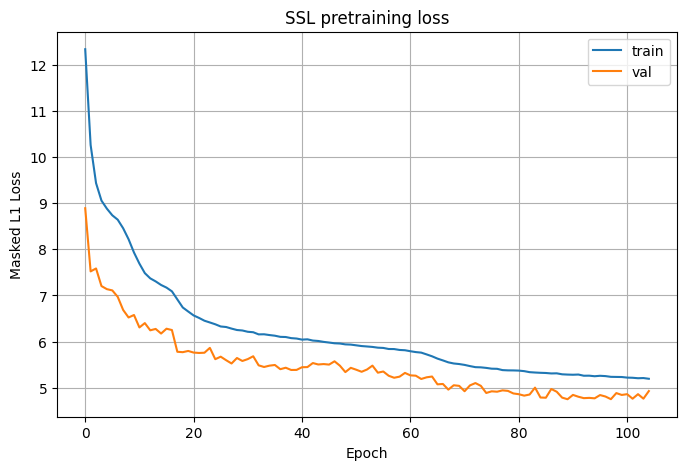

In [49]:
# Небольшой график loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Masked L1 Loss")
plt.title("SSL pretraining loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "ssl_loss_curve.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "ssl_loss_curve.pdf"), bbox_inches="tight")
plt.show()

## 10) Быстрая визуальная проверка реконструкций

In [50]:
print("orig min/max:", orig.min(), orig.max())
print("recon min/max:", reconstructed.min(), reconstructed.max())

NameError: name 'orig' is not defined

In [ ]:
model.eval()

x = next(iter(loader)).to(device)
x_masked, mask = batch_time_block_mask(x)

with torch.no_grad():
    recon, z = model(x_masked)

# возьмём первый пример и первый канал
orig = x[0, 0].cpu().numpy()
masked = x_masked[0, 0].cpu().numpy()
reconstructed = recon[0, 0].cpu().numpy()
mask_np = mask[0].cpu().numpy()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(orig * 1e6, label="Original")
plt.plot(masked * 1e6, label="Masked")
plt.plot(reconstructed * 1e6, label="Reconstructed")
plt.legend()
plt.title("SSL Reconstruction Check (µV)")
plt.show()

In [ ]:
print("Bottleneck shape:", z.shape)

## 10) Артефакты на выходе

In [ ]:
# Сохранить энкодер отдельно
torch.save(
    {
        "inc": model.inc.state_dict(),
        "down1": model.down1.state_dict(),
        "down2": model.down2.state_dict(),
        "down3": model.down3.state_dict(),
        "down4": model.down4.state_dict(),
    },
    "/kaggle/working/encoder_ssl_02.pt"
)

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/unet_ssl_final_v2.pt")